In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv('monster_energy_dashboard_dataset.csv')

In [3]:
df.head()

,Date,Region,Country,Product,Category,Sales_Channel,Units_Sold,Unit_Price_USD,Discount,Revenue_USD,Cost_USD,Profit_USD,Customer_Rating
0,2026-05-01,Asia Pacific,Thailand,Monster Ultra Fiesta Mango,Ultra,Online,201,1.97,0.05,376.17,215.11,161.06,4.1
1,2025-10-01,Middle East & Africa,Saudi Arabia,Monster Pacific Punch,Juice,Distributor,885,1.50,0.10,1194.75,617.30,577.45,4.1
2,2026-01-01,North America,Mexico,Java Monster Mean Bean,Coffee,Distributor,590,1.92,0.10,1019.52,687.92,331.60,4.0
3,2024-03-01,Middle East & Africa,South Africa,Monster Pipeline Punch,Juice,Convenience Store,100,2.85,0.00,285.00,190.89,94.11,4.9
4,2024-09-01,Europe,Italy,Monster Energy Zero Sugar,Zero Sugar,Online,1443,2.22,0.10,2883.11,1454.26,1428.85,4.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1000 non-null   object 
 1   Region           1000 non-null   object 
 2   Country          1000 non-null   object 
 3   Product          1000 non-null   object 
 4   Category         1000 non-null   object 
 5   Sales_Channel    1000 non-null   object 
 6   Units_Sold       1000 non-null   int64  
 7   Unit_Price_USD   1000 non-null   float64
 8   Discount         1000 non-null   float64
 9   Revenue_USD      1000 non-null   float64
 10  Cost_USD         1000 non-null   float64
 11  Profit_USD       1000 non-null   float64
 12  Customer_Rating  1000 non-null   float64
dtypes: float64(6), int64(1), object(6)
memory usage: 101.7+ KB


In [5]:
df.describe

<bound method NDFrame.describe of            Date                Region       Country  \
0    2026-05-01          Asia Pacific      Thailand   
1    2025-10-01  Middle East & Africa  Saudi Arabia   
2    2026-01-01         North America        Mexico   
3    2024-03-01  Middle East & Africa  South Africa   
4    2024-09-01                Europe         Italy   
..          ...                   ...           ...   
995  2025-07-01                Europe            UK   
996  2024-11-01         North America           USA   
997  2024-05-01  Middle East & Africa  Saudi Arabia   
998  2024-10-01         North America           USA   
999  2024-04-01          Asia Pacific         Japan   

                          Product    Category      Sales_Channel  Units_Sold  \
0      Monster Ultra Fiesta Mango       Ultra             Online         201   
1           Monster Pacific Punch       Juice        Distributor         885   
2          Java Monster Mean Bean      Coffee        Distributor 

In [6]:
df.isnull().sum()

Date               0
Region             0
Country            0
Product            0
Category           0
Sales_Channel      0
Units_Sold         0
Unit_Price_USD     0
Discount           0
Revenue_USD        0
Cost_USD           0
Profit_USD         0
Customer_Rating    0
dtype: int64

In [7]:
df.dtypes

Date                object
Region              object
Country             object
Product             object
Category            object
Sales_Channel       object
Units_Sold           int64
Unit_Price_USD     float64
Discount           float64
Revenue_USD        float64
Cost_USD           float64
Profit_USD         float64
Customer_Rating    float64
dtype: object

In [8]:
# for changing the format of date column
df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%d/%m/%y")
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%y")

In [9]:
df.head(2)

,Date,Region,Country,Product,Category,Sales_Channel,Units_Sold,Unit_Price_USD,Discount,Revenue_USD,Cost_USD,Profit_USD,Customer_Rating
0,2026-05-01,Asia Pacific,Thailand,Monster Ultra Fiesta Mango,Ultra,Online,201,1.97,0.05,376.17,215.11,161.06,4.1
1,2025-10-01,Middle East & Africa,Saudi Arabia,Monster Pacific Punch,Juice,Distributor,885,1.50,0.10,1194.75,617.30,577.45,4.1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1000 non-null   datetime64[ns]
 1   Region           1000 non-null   object        
 2   Country          1000 non-null   object        
 3   Product          1000 non-null   object        
 4   Category         1000 non-null   object        
 5   Sales_Channel    1000 non-null   object        
 6   Units_Sold       1000 non-null   int64         
 7   Unit_Price_USD   1000 non-null   float64       
 8   Discount         1000 non-null   float64       
 9   Revenue_USD      1000 non-null   float64       
 10  Cost_USD         1000 non-null   float64       
 11  Profit_USD       1000 non-null   float64       
 12  Customer_Rating  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(5)
memory usage: 101.7+ KB


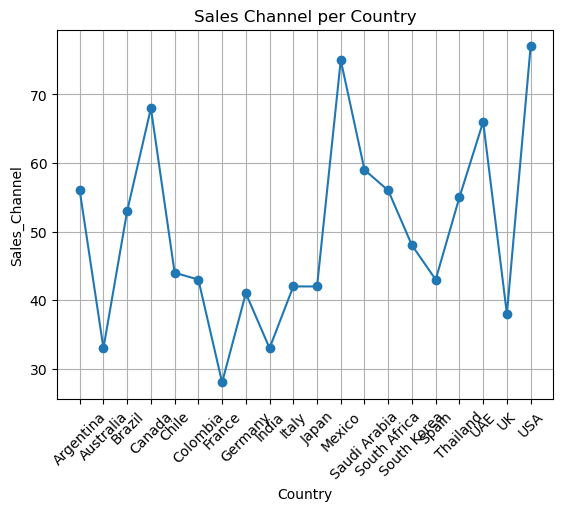

In [11]:
# Line chart
country_channel = df.groupby("Country")["Sales_Channel"].count()

plt.plot(country_channel.index, country_channel.values, marker="o")

plt.xlabel("Country")
plt.ylabel("Sales_Channel")
plt.title("Sales Channel per Country")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

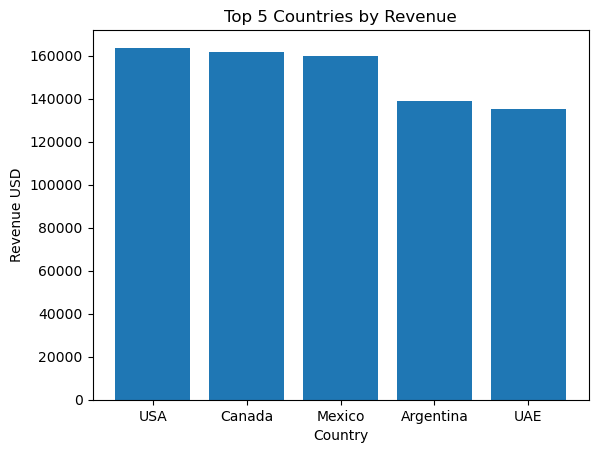

In [12]:
# Bar Chart
country_revenue = df.groupby("Country")["Revenue_USD"].sum()

top_5 = country_revenue.sort_values(ascending=False).head(5)

plt.bar(top_5.index, top_5.values)

plt.xlabel("Country")
plt.ylabel("Revenue USD")
plt.title("Top 5 Countries by Revenue")
plt.show()

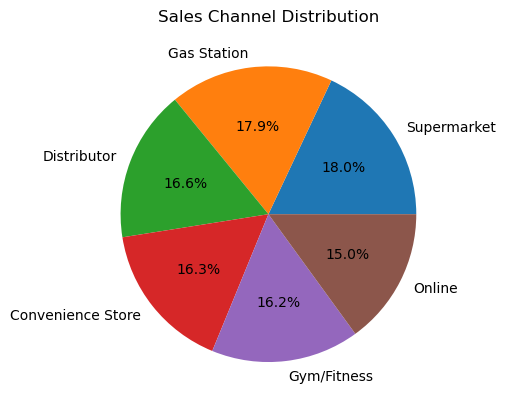

In [13]:
# Pie Chart
channel_count = df["Sales_Channel"].value_counts()

plt.pie(channel_count.values, labels=channel_count.index, autopct="%1.1f%%")

plt.title("Sales Channel Distribution")
plt.show()

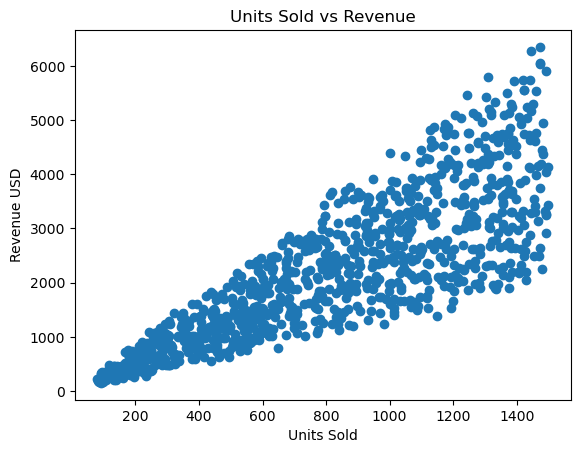

In [14]:
# Scatter Plot
plt.scatter(df["Units_Sold"], df["Revenue_USD"])

plt.xlabel("Units Sold")
plt.ylabel("Revenue USD")
plt.title("Units Sold vs Revenue")
plt.show()

In [15]:
df.to_excel("cleaned_sales_data.xlsx", index=False)

In [16]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Analysis.ipynb',
 'cleaned_sales_data.csv',
 'cleaned_sales_data.xlsx',
 'monster_energy_dashboard_dataset.csv']